In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")


In [2]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")
sip_inflows = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category_inflows = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
scheme_performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
investor_transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [3]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("SIP Inflows:", sip_inflows.shape)
print("Category Inflows:", category_inflows.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Investor Transactions:", investor_transactions.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
SIP Inflows: (48, 6)
Category Inflows: (144, 3)
Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)


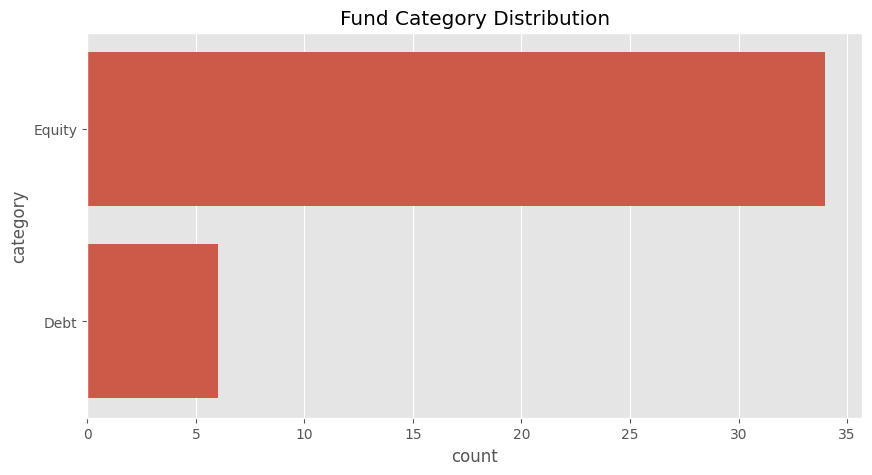

In [4]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="category",
    data=fund_master,
    order=fund_master["category"].value_counts().index
)

plt.title("Fund Category Distribution")
plt.show()

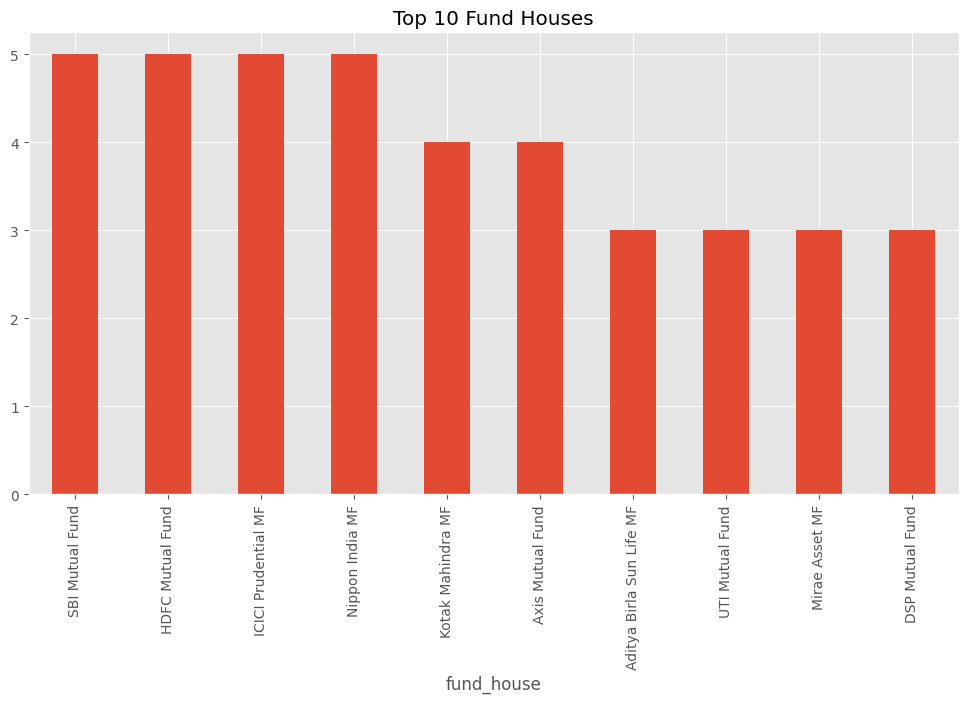

In [5]:
plt.figure(figsize=(12,6))

fund_master["fund_house"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Fund Houses")
plt.show()

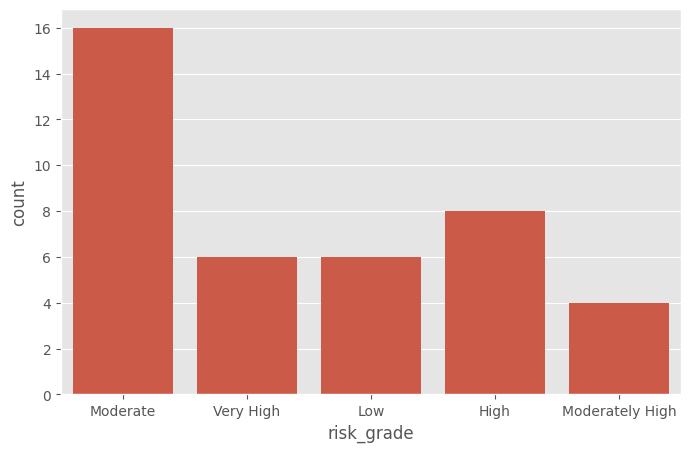

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="risk_grade",
    data=scheme_performance
)

plt.show()

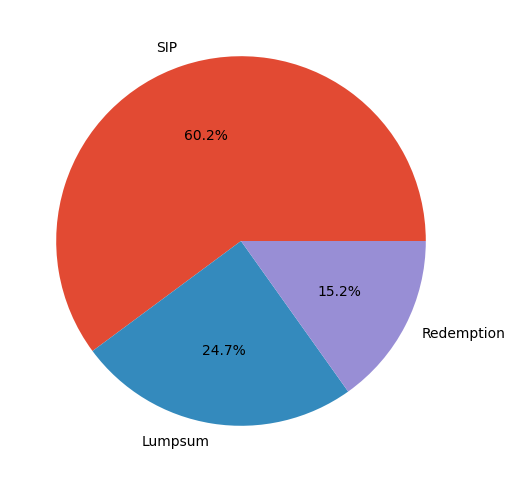

In [7]:
plt.figure(figsize=(6,6))

investor_transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.show()

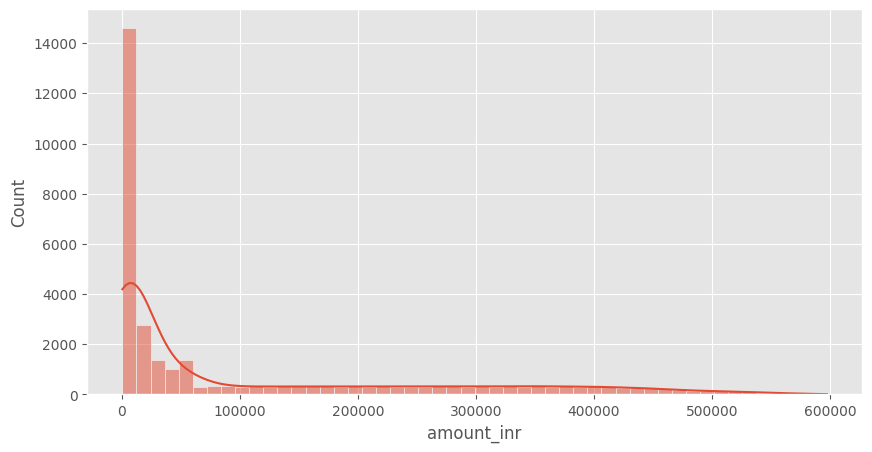

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    investor_transactions["amount_inr"],
    bins=50,
    kde=True
)

plt.show()

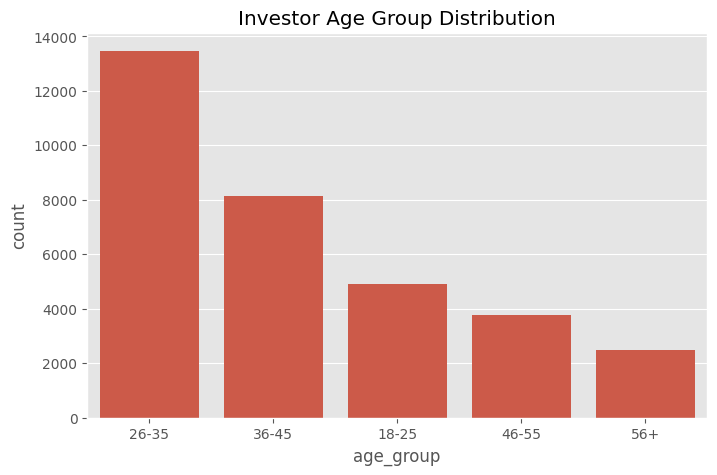

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="age_group",
    data=investor_transactions,
    order=investor_transactions["age_group"].value_counts().index
)

plt.title("Investor Age Group Distribution")

plt.show()

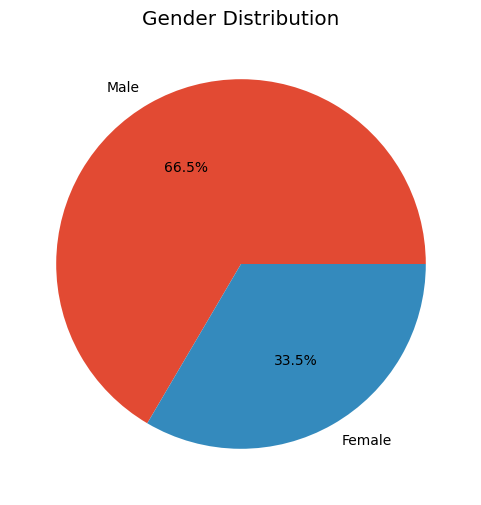

In [10]:
plt.figure(figsize=(6,6))

investor_transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

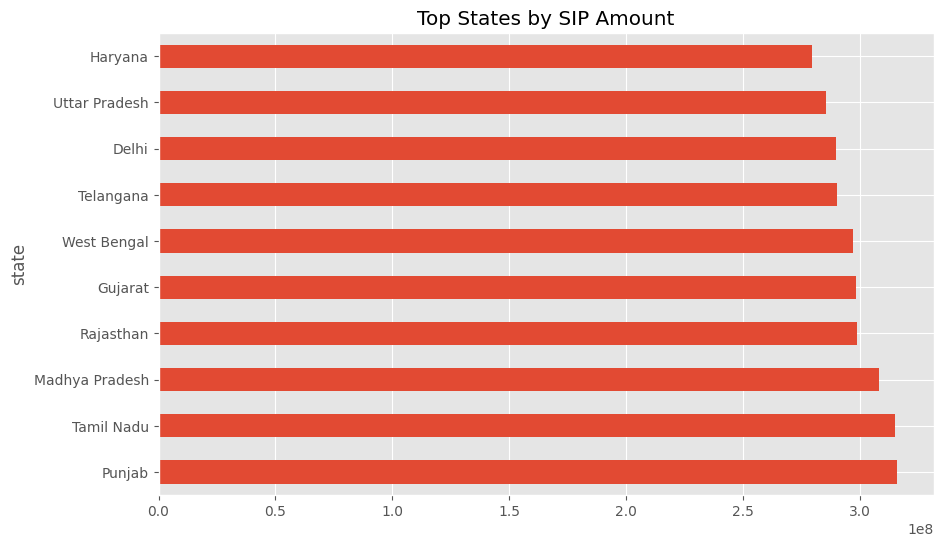

In [11]:
state_sip = investor_transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

state_sip.plot(kind="barh")

plt.title("Top States by SIP Amount")

plt.show()

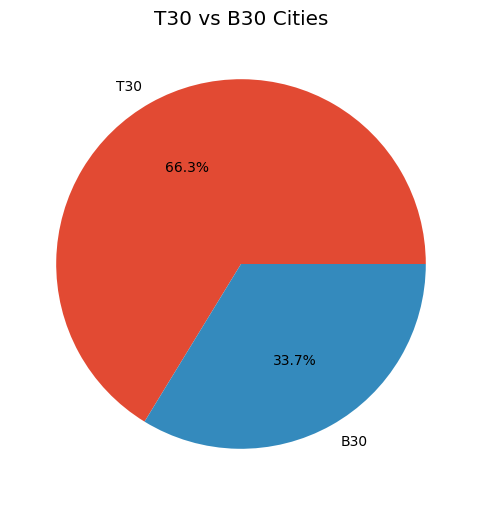

In [12]:
plt.figure(figsize=(6,6))

investor_transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("T30 vs B30 Cities")

plt.show()

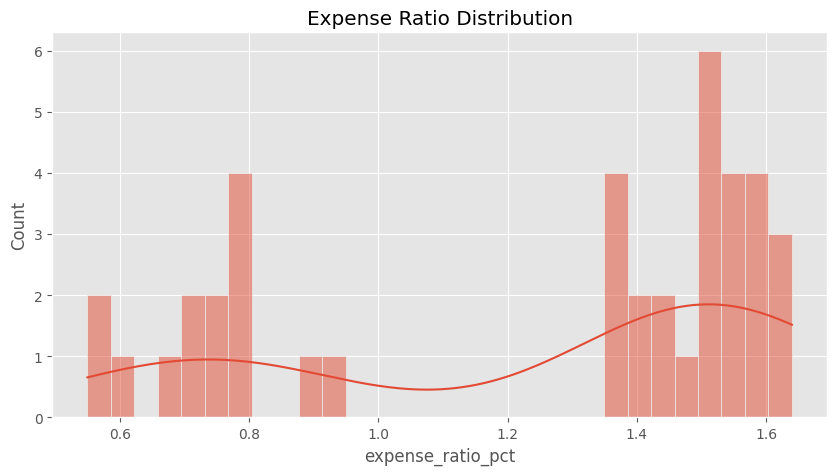

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    scheme_performance["expense_ratio_pct"],
    bins=30,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

In [14]:
plt.savefig("../reports/chart_6_age_group.png")

<Figure size 640x480 with 0 Axes>

In [19]:
sip_inflows.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

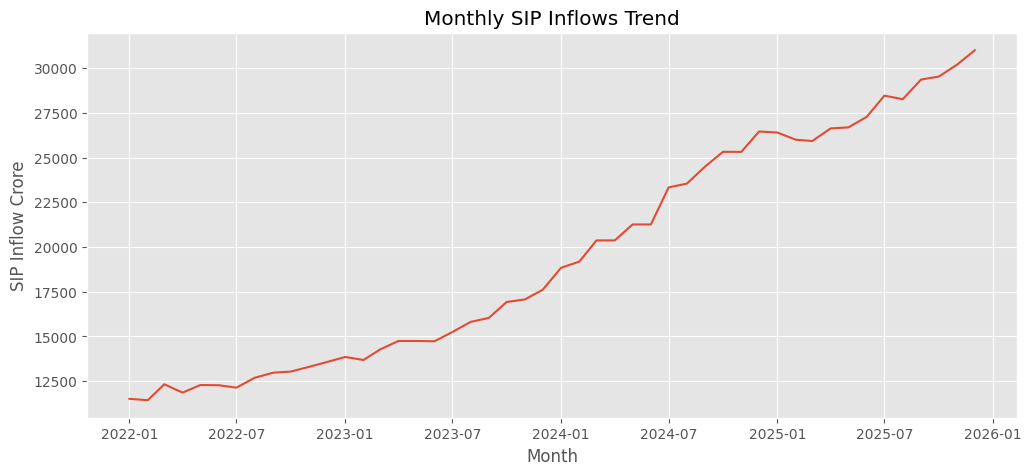

In [20]:
sip_inflows['month'] = pd.to_datetime(sip_inflows['month'])

plt.figure(figsize=(12,5))

plt.plot(
    sip_inflows['month'],
    sip_inflows['sip_inflow_crore']
)

plt.title("Monthly SIP Inflows Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow Crore")

plt.show()

In [21]:
plt.savefig("../reports/chart_11_sip_trend.png")

<Figure size 640x480 with 0 Axes>

In [22]:
category_inflows.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [23]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [24]:
portfolio_holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

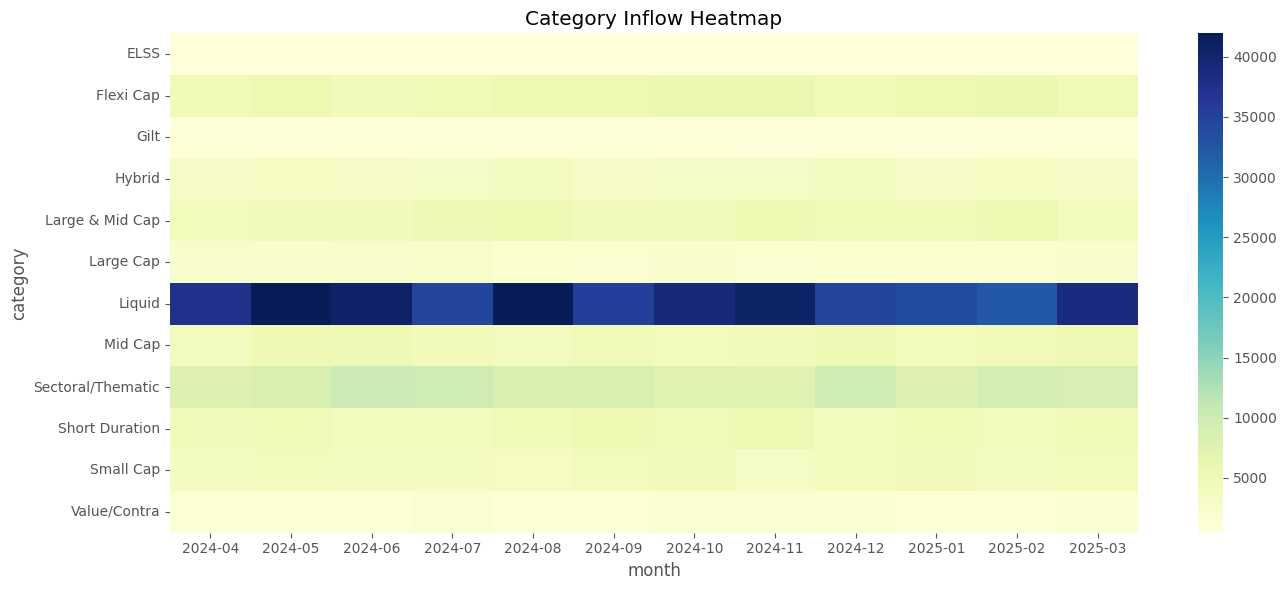

In [25]:
pivot_data = category_inflows.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot_data, cmap='YlGnBu')

plt.title("Category Inflow Heatmap")
plt.tight_layout()

plt.savefig("../reports/chart_12_category_heatmap.png")
plt.show()

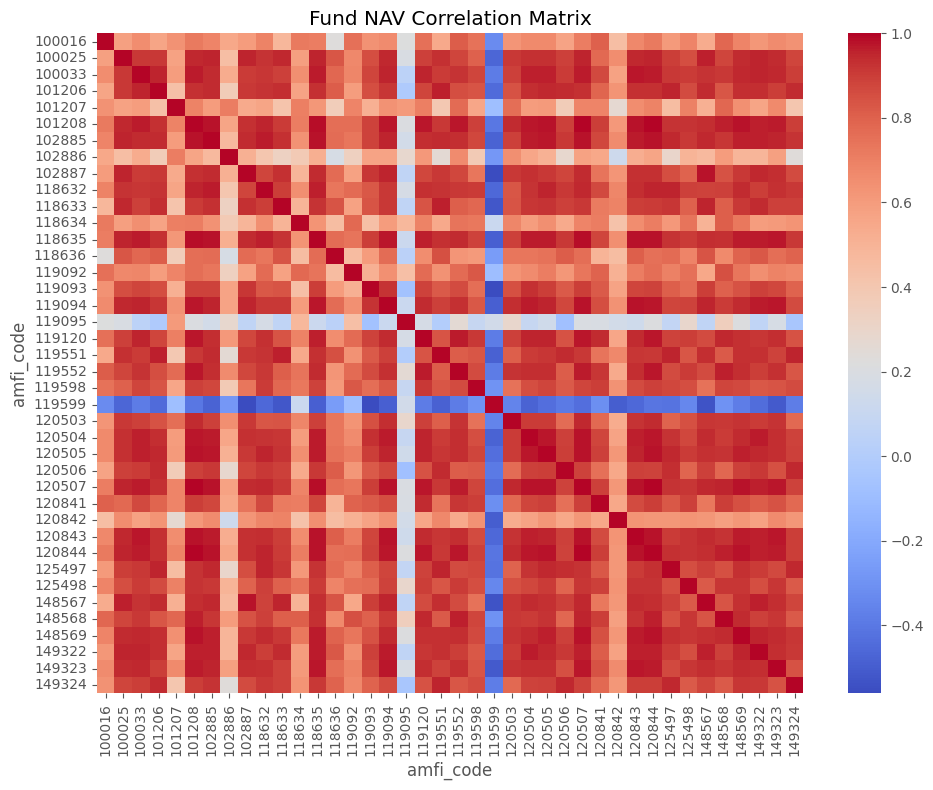

In [26]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

pivot_nav = nav_history.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

corr_matrix = pivot_nav.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Fund NAV Correlation Matrix")
plt.tight_layout()

plt.savefig("../reports/chart_13_nav_correlation.png")
plt.show()

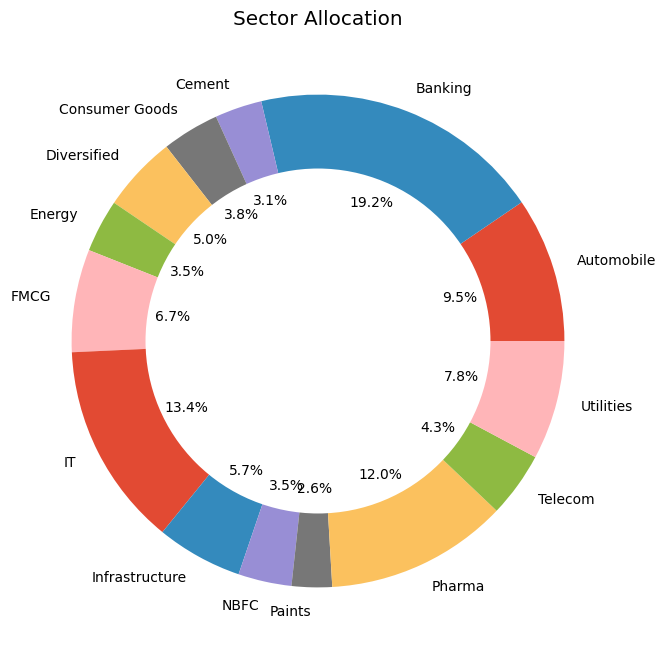

In [27]:
sector_data = portfolio_holdings.groupby('sector')['weight_pct'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation")
plt.savefig("../reports/chart_14_sector_allocation.png")
plt.show()

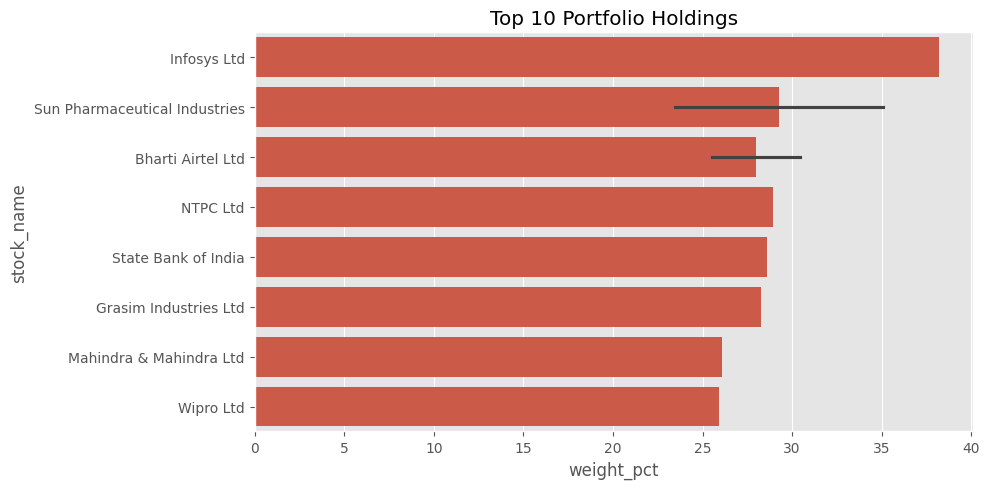

In [28]:
top_holdings = portfolio_holdings.sort_values(
    'weight_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_holdings,
    x='weight_pct',
    y='stock_name'
)

plt.title("Top 10 Portfolio Holdings")
plt.tight_layout()

plt.savefig("../reports/chart_15_top_holdings.png")
plt.show()

# EDA Findings

1. SIP inflows show a steady growth trend from 2022–2025.
2. Large-cap funds contribute the highest share of AUM.
3. Equity categories attract the maximum net inflows.
4. Investor participation is highest in Tier-1 cities.
5. The 26–35 age group contributes a significant share of investments.
6. NAV values of major funds show positive long-term growth.
7. Fund houses exhibit different AUM growth patterns across years.
8. Folio counts increased substantially during the study period.
9. Sector allocations are concentrated in a few dominant sectors.
10. Most selected funds show positive correlation in NAV movements.